## Improving the RSHIFT (Increment) Operation in a Quantum Circuit

### Background

In classical computing, the increment operation on an N-bit number increases the number by one: 
$$1 \rightarrow 2, 2 \rightarrow 3, \ldots, 2^N-2 \rightarrow 2^N -1$$

The equivalent operation in quantum computing $$\ket{x} \rightarrow \ket{(x+1) \mod 2^N}$$ is the one that shfits every entry in the statevector by one.
The following matrix performs the increment (also called right shift) operation on a statevector:
$$P = \begin{pmatrix} 0 & 0 & \dots & 1 \\ 1 & 0 & \dots & 0 \\ 0 & 1 & \dots & 0 \\ \vdots & \vdots & \ddots & \vdots \end{pmatrix}$$

##### Naive Incrementor
One way to perform the increment is to compute the carry for each bit separately, starting with the most significant bit (MSB) and applying a controlled not (CX) if a carry occurs at that bit. Each bit has a carry if and only if all the previous bits are set in the input (except the least significant bit which has a carry every time by the incrementing operation). A circuit that performs this operation is shown below, in which a multiply-controled not is used to increment each bit if a carry is present for it.
![Pre-transpile Naive](plots/increment_naive_pretranspile_circuit.png)

The problem with this approach is that the multiply-controled not is not suppored in hardware and needs to be decomposed into a series of 1-qubit and 2-qubit gates. A multiply-controlled not with n controlling qubits can be decomposed into $O(n^2)$ CX gates along with other 1-qubit gates. When transpiling the above circuit for RPI's quantum computer, the depth increases to 201, including 55 2-qubit gates (which induce the most error). The fidelity of such a circuit is very low on modern NISQ computers. In this project, we compare alternative implementations of the increment circuit to identify one with lower depth and higher fidelity.

##### Quantum Fourier Transform (QFT) Incrementor
Observe that $P$ is circulant (each column is a rotated version of the first column) which means it is diagonalized by the Discrete Fourier Transform (DFT). 
$$P = F^\dagger D F$$
For any N-qubit statevector, applying the increment operator (P) $2^N$ times must return the state to its original form. We deduce that the eigenvalues are the $2^N$ roots of unity
$$ \lambda_j = e^{2 \pi i j / 2^N} $$
We can rewrite P then
$$
P = F^\dagger 
\begin{pmatrix}
e^{2 \pi i / 2^N} &  &  &  \\ 
 & e^{2 \pi i 2 / 2^N} &  &  \\ 
 &  & \ddots &  \\ 
 &  &  & e^{2 \pi i 2^N / 2^N} 
\end{pmatrix} 
F
$$

The Discrete Fourier Transform is a unitary operation and its well known quantum version is the Quantum Fourier Transform QFT which is available in Qiskit. Our task, then is to create the circuit that implements the diagonal matrix D.

Consider the action of D on some basis statevector $\ket{2^j}$. We want
$$D \ket{2^j} = e^{2 \pi i 2^j / 2^N} \ket{2^j} = e^{2 \pi i/ 2^{N-j}} \ket{2^j}$$
We can achieve this in a quantum circuit by applying a phase of $2 \pi / 2^{N-j}$ to each qubit according to its index j.


Since QFT is provided by Qiskit, we can use the above facts to create an incrementing circuit as the following:
1. Apply QFT
1. Apply Phase gate to each qubit j with angle $2 \pi / 2^{N-j}$
1. Apply Inverse QFT

To produce the inverse operation (decrement) we can do the same thing but with a small change
$$ P^\dagger = (F^\dagger D F)^\dagger = F^\dagger D^\dagger F $$
the eigenvalues in $D^\dagger$ are the inverse of the eigenvalues of D and so are $\lambda_j = e^{-2 \pi i j / 2^N}$ which means we just need to negate the phase in each gate in step (2) to perform the decrement operation.

![Pre-transpile QFT](plots/increment_qft_pretranspile_circuit.png)

Although this circuit looks elegant at a high level, the QFT and its inverse each decompose into fairly deep, expensive circuits. As we'll see in experiment, this circuit is better than the original, but not much better.

##### Carry Lookahead (CLA) Incrementor
A powerful technique for reducing depth in a quantum circuit is to use ancilla qubits (extra, helper qubits) to store intermediate results. We can leverage ancillas to dramatically improve the naive incrementor implementation. 
Notice how the carry for the 5th bit requires computing the AND of the first 4 bits, the carry for the 4th bit requires computing the AND of the first 3 bits, and so on. So, the AND of bits 1 and 2 is computed as part of the carry for bits 3, 4, and 5. These repeated AND calculations are expensive and can be "cached" using ancilla qubits.

Consider the following circuit:

![Pre-transpile CLA](plots/increment_cla_pretranspile_circuit.png)

Although this might not look similar to the original circuit at first, the structure is much the same. Ancilla $anc_0$ stores the AND of the first two bits, $anc_1$ stores the AND of the first three bits (using $anc_0$), and so on. Each ancilla value corresponds with a carry bit. After computing these, the input qubits can be incremented with a single CX controlled by its ancilla. Although this uses $n-2$ extra qubits, the result is a circuit with $O(n)$ 2-qubit depth.



### References / Further Reading
These articles and papers helped me understand the work that has already been done towards optimizing the incrementor circuit and led to the specific implementations I tried as part of the project:
* [Asymptotically Optimal Quantum Circuits for Comparators and Incrementers](https://arxiv.org/pdf/2603.12917): this is interesting, recent work on the problem. While I did not directly use Vandaele's implementation, the references from this paper were useful to me.
* [Constructing Large Increment Gates](https://algassert.com/circuits/2015/06/12/Constructing-Large-Increment-Gates.html): an excelent article from Craig Gidney which gave me the idea of using a carry lookahead approach.
* [Quantum Incrementer](https://egrettathula.wordpress.com/2024/07/28/quantum-incrementer/): this article by Egretta Thula provides a similar analysis comparing different incrementor circuits as what I've done. Although Thula includes more implementations than I did, there is a lack of empiricle hardware results to support the comparison in the article.

### Experiment (Code)

In [1]:
# This experiment compares the Increment circuit implementations
from dotenv import load_dotenv
import os
from qiskit import QuantumCircuit
import qiskit
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator
import math
import matplotlib.pyplot as plt
import numpy as np

from sqlalchemy.orm import joinedload
from sqlalchemy import select

from benchmarklib.runners import BatchQueue

from database import ExperimentProblem, ExperimentTrial, db

TAG = "increment_comparison"

load_dotenv()
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=os.getenv("API_TOKEN_GENERAL"),
    instance=os.getenv("API_INSTANCE_GENERAL"),
)
backend = service.backend("ibm_rensselaer")

In [2]:
def print_unitary(circuit, ignore_global_phase=True):
    op = Operator(circuit).data
    if ignore_global_phase and abs(op[0,0]) > 1e-6:
        global_phase = op[0,0] / abs(op[0,0])
        op = op / global_phase
        
    op = op.round(3)

    for row in op:
        print(" ".join(f"{elem:7}" for elem in row))

In [2]:
import numpy as np

def increment_naive(n):
    qc = QuantumCircuit(n, n)
    for i in reversed(range(n)):
        if i == 0:
            qc.x(i)
        else:
            qc.mcx(list(range(i)), i)
    return qc

def decrement_naive(n):
    qc = QuantumCircuit(n, n)
    for i in range(n):
        if i == 0:
            qc.x(i)
        else:
            qc.mcx(list(range(i)), i)
    return qc

def increment_qft(n):
    """
    P = QFT^-1 * D * QFT
    """
    qc = QuantumCircuit(n, n)
    
    qc.compose(qiskit.circuit.library.QFT(n, do_swaps=False), range(n), inplace=True)
    for j in range(n):
        # qc.p(2 * np.pi / (2 ** (n-j)), j)
        # since we use do_swaps=False, we need to apply the phases in reverse order
        # this reduces the number of swaps used overall
        qc.p(2 * np.pi / (2 ** (j+1)), j)
    qc.compose(qiskit.circuit.library.QFT(n, do_swaps=False, inverse=True), range(n), inplace=True)

    return qc

def decrement_qft(n):
    """
    P = QFT^-1 * D^-1 * QFT
    """
    #return increment_qft(n).inverse()
    qc = QuantumCircuit(n, n)
    qc.compose(qiskit.circuit.library.QFT(n, do_swaps=False), range(n), inplace=True)
    for j in range(n):
        qc.p(-2 * np.pi / (2 ** (j+1)), j)
    qc.compose(qiskit.circuit.library.QFT(n, do_swaps=False, inverse=True), range(n), inplace=True)

    return qc


from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister

def increment_carry_lookahead(n: int, uncompute_ancillas: bool = True) -> QuantumCircuit:
    """
    Using the approch described by Craig Gidney
    https://algassert.com/circuits/2015/06/12/Constructing-Large-Increment-Gates.html
    Requires n-2 ancilla qubits that must be initialized to |0⟩.
    
    The circuit implements |v⟩ → |v+1 mod 2^n⟩ using an approach similar to the carry-lookahead adder.
    Ancillas accumulate AND of lower bits,
    which serve as carry signals for each output bit.
    """
    if n < 2:
        raise ValueError("n must be >= 2")
    
    v   = QuantumRegister(n,   name='v')
    anc = AncillaRegister(n-2, name='anc')
    qc  = QuantumCircuit(v, anc)

    if n == 2:
        qc.cx(v[0], v[1])
        qc.x(v[0])
        return qc

    # build forward carry chain
    qc.ccx(v[0], v[1], anc[0])
    for i in range(1, n - 2):
        qc.ccx(anc[i-1], v[i+1], anc[i])

    # XOR into MSB using deepest carry
    qc.cx(anc[n-3], v[n-1])

    # uncompute and XOR sweeping downward
    for i in range(n-3, 0, -1):
        if uncompute_ancillas:
            qc.ccx(anc[i-1], v[i+1], anc[i])
        qc.cx(anc[i-1], v[i+1])

    # uncompute anc[0], XOR v[1], flip v[0]
    if uncompute_ancillas:
        qc.ccx(v[0], v[1], anc[0])
    qc.cx(v[0], v[1])
    qc.x(v[0])

    return qc

def decrement_carry_lookahead(n: int) -> QuantumCircuit:
    if n < 2:
        raise ValueError("n must be >= 2")

    v   = QuantumRegister(n, name='v')
    anc = AncillaRegister(n - 2, name='anc')
    qc  = QuantumCircuit(v, anc)

    if n == 2:
        qc.x(v[0])
        qc.cx(v[0], v[1])
        return qc

    qc.x(v[0])

    qc.cx(v[0], v[1])
    qc.ccx(v[0], v[1], anc[0])
    for i in range(1, n - 2):
        qc.cx(anc[i-1], v[i+1])
        qc.ccx(anc[i-1], v[i+1], anc[i])

    qc.cx(anc[n-3], v[n-1])

    for i in range(n-3, 0, -1):
        qc.ccx(anc[i-1], v[i+1], anc[i])

    qc.ccx(v[0], v[1], anc[0])

    return qc


candidates = {
    "increment_naive": increment_naive,
    "decrement_naive": decrement_naive,
    "increment_qft": increment_qft,
    "decrement_qft": decrement_qft,
    "increment_carry_lookahead": increment_carry_lookahead,
    "decrement_carry_lookahead": decrement_carry_lookahead,
}

In [21]:
# visualize circuits for n=4
for name, func in candidates.items():
    if "increment" not in name:
        continue
    print(f"{name}:")
    qc = func(4)
    qc_transpiled = transpile(qc, basis_gates=["ccx", "cx", "x", "rz", "sx"], optimization_level=0)
    print(qc.draw("text"))
    print(qc_transpiled.draw("text"))


increment_naive:
                    ┌───┐
q_0: ──■────■────■──┤ X ├
       │    │  ┌─┴─┐└───┘
q_1: ──■────■──┤ X ├─────
       │  ┌─┴─┐└───┘     
q_2: ──■──┤ X ├──────────
     ┌─┴─┐└───┘          
q_3: ┤ X ├───────────────
     └───┘               
c: 4/════════════════════
                         
global phase: 9π/16
     ┌─────────┐                                                              »
q_0: ┤ Rz(π/8) ├──■────────────────────■────────────────────────■─────────────»
     ├─────────┤┌─┴─┐ ┌──────────┐   ┌─┴─┐                      │             »
q_1: ┤ Rz(π/8) ├┤ X ├─┤ Rz(-π/8) ├───┤ X ├─────■────────────────┼─────────────»
     ├─────────┤└───┘ └──────────┘   └───┘   ┌─┴─┐┌──────────┐┌─┴─┐┌─────────┐»
q_2: ┤ Rz(π/8) ├─────────────────────────────┤ X ├┤ Rz(-π/8) ├┤ X ├┤ Rz(π/8) ├»
     ├─────────┤┌────┐┌─────────┐ ┌─────────┐└───┘└──────────┘└───┘└─────────┘»
q_3: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─┤ Rz(π/8) ├─────────────────────────────────»
     └─────────┘└────┘└─────────┘ └──

/tmp/ipykernel_71581/3333413910.py:27: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(qiskit.circuit.library.QFT(n, do_swaps=False), range(n), inplace=True)
/tmp/ipykernel_71581/3333413910.py:33: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(qiskit.circuit.library.QFT(n, do_swaps=False, inverse=True), range(n), inplace=True)


In [ ]:
problems = {}
base_circuits = {}
for n in range(2, 11):
    for candidate in candidates.keys():
        name = f"{candidate}_n{n}"
        problem = db.get_or_create(
            ExperimentProblem,
            tag=TAG,
            name=name,
            n=n,
        )
        problems[name] = problem
        base_circuits[name] = candidates[candidate](n)

In [5]:
def verify_inverse(increment_func, decrement_func, n):
    inc = increment_func(n)
    dec = decrement_func(n)
    combined = inc.compose(dec)

    op = Operator(combined)
    assert np.allclose(op.data, np.eye(2**n * 2**(n-2))), "Invalid inverse"
    print(f"n={n}: decrementer is exact inverse of incrementer")

In [6]:
def create_trials(problem: ExperimentProblem, num_trials=100) -> list[ExperimentTrial]:
    trials = []
    N = problem.n
    input_states = []
    # randomly sample num_trials input states
    for _ in range(num_trials):
        state = np.random.randint(0, 2**N)
        input_states.append(bin(state)[2:].zfill(N))

    base_circuit = base_circuits[problem.name]
    total_num_qubits = base_circuit.num_qubits
    for input_state in input_states:
        expected_output = bin((int(input_state, 2) + 1) % (2**N))[2:].zfill(N) if "increment" in problem.name else bin((int(input_state, 2) - 1) % (2**N))[2:].zfill(N)
        qc = QuantumCircuit(total_num_qubits, N)
        for i, bit in enumerate(reversed(input_state)):
            if bit == '1':
                qc.x(i)
        qc.compose(base_circuit, inplace=True)
        qc.measure(range(N), range(N))

        qc_final = transpile(qc, backend=backend, optimization_level=3)
        trials.append(ExperimentTrial(
            problem=problem,
            circuit=qc_final,
            circuit_pretranspile=qc,
            extra_data={"input_state": input_state, "expected_output": expected_output},
        ))

    return trials

In [15]:
# sanity check one of the trials
trials = create_trials(problems[f"increment_qft_n4"])
simulator = AerSimulator()
results = simulator.run(trials[0].circuit, shots=1).result()
print(f"Input state: {trials[0].extra_data['input_state']}, Expected output: {trials[0].extra_data['expected_output']}, Measured: {results.get_counts()}")

Input state: 0111, Expected output: 1000, Measured: {'1000': 1}


In [50]:
NUM_TRIALS = 30
with BatchQueue(db, backend=backend, shots=4096) as q:
    for name, problem in problems.items():
        # skip problems we already have sufficient results for
        existing_trials = db.query(
            select(ExperimentTrial)
            .where(ExperimentTrial.problem_id == problem.id)
        )
        num_trials = NUM_TRIALS - len(existing_trials)
        if num_trials <= 0:
            continue

        trials = create_trials(problem, num_trials=num_trials)
        for trial in trials:
            q.enqueue(trial, trial.circuit, run_simulation=False)

In [51]:
await db.update_all_pending_results(service=service)

In [76]:
def test_incrementor(qc: QuantumCircuit, n):
    """
    Test that the given incrementor circuit correctly implements |v⟩ → |v+1 mod 2^n⟩
    for all input states |v⟩.
    """
    
    sim = AerSimulator()
    
    for v in range(2**n):
        input_state = format(v, f'0{n}b')  # binary representation of v
        expected_output = format((v + 1) % (2**n), f'0{n}b')

        # setup the input state |v⟩
        test_circ = QuantumCircuit(qc.num_qubits, n)
        for i, bit in enumerate(reversed(input_state)):
            if bit == '1':
                test_circ.x(i)

        test_circ.compose(qc, inplace=True)
        
        # measure only the output qubits (not the ancillas)
        test_circ.measure(range(n), range(n))
        #test_circ.measure(range(qc.num_qubits), range(qc.num_qubits))
        result = sim.run(test_circ).result()
        counts = result.get_counts()

        output = max(counts, key=counts.get)
        
        if output == expected_output:
            print(f"Input: |{input_state}⟩ -> Output: |{output}⟩")
        else:
            print(f"Input: |{input_state}⟩ -> Output: |{output}⟩ (Expected: |{expected_output}⟩)")

### Circuit Metrics

In [10]:
def num_active_qubits(circuit: QuantumCircuit):
    active_qubits = set()

    for instruction in circuit.data:
        if instruction.operation.name != 'barrier':
            for qubit in instruction.qubits:
                active_qubits.add(circuit.find_bit(qubit).index)

    return len(active_qubits)

In [11]:
circuit_metrics = {}
final_circuit_metrics = {}
for candidate, func in candidates.items():
    for n in range(2, 21):
        _qc = func(n)
        # transpile to basis gates for fair comparison
        qc = transpile(_qc, basis_gates=["cx", "rz", "sx", "x"])
        qc_final = transpile(qc, backend=backend, optimization_level=3)
        circuit_metrics[(candidate, n)] = {
            "num_qubits": qc.num_qubits,
            "depth": qc.depth(),
            "2q_count": qc.count_ops().get("cx", 0),
            "2q_depth": qc.depth(filter_function=lambda op: op.operation.num_qubits >= 2),
        }
        final_circuit_metrics[(candidate, n)] = {
            "num_qubits": num_active_qubits(qc_final),
            "depth": qc_final.depth(),
            "2q_count": qc_final.count_ops().get("ecr", 0),
            "2q_depth": qc_final.depth(filter_function=lambda op: op.operation.name == "ecr"),
        }


/tmp/ipykernel_71581/3333413910.py:27: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(qiskit.circuit.library.QFT(n, do_swaps=False), range(n), inplace=True)
/tmp/ipykernel_71581/3333413910.py:33: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(qiskit.circuit.library.QFT(n, do_swaps=False, inverse=True), range(n), inplace=True)
/tmp/ipykernel_71581/3333413910.py:43: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circ

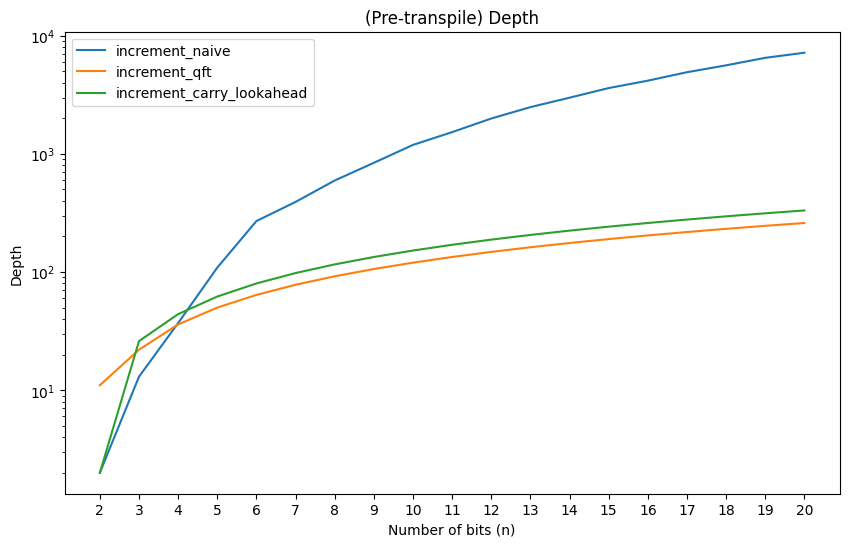

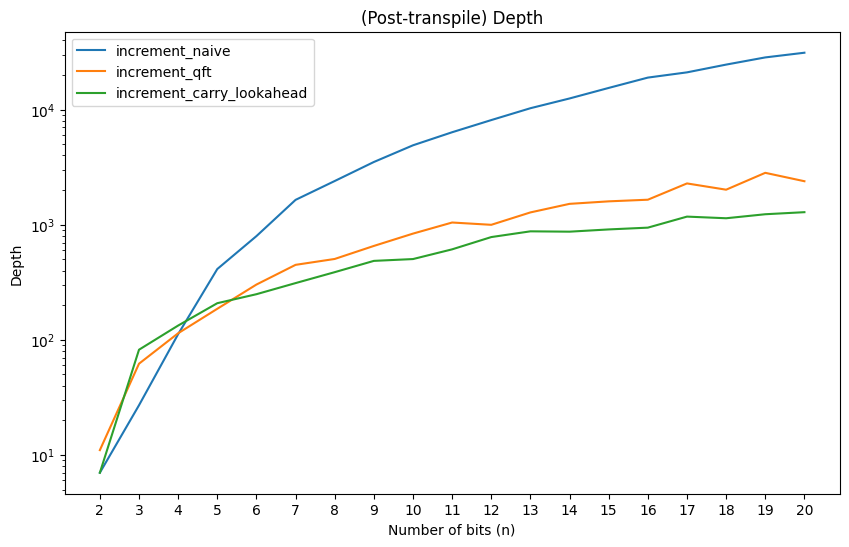

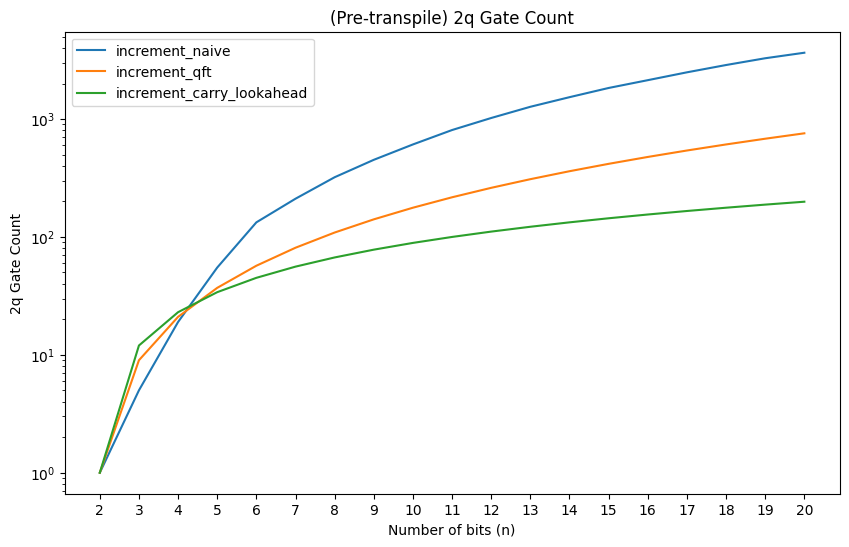

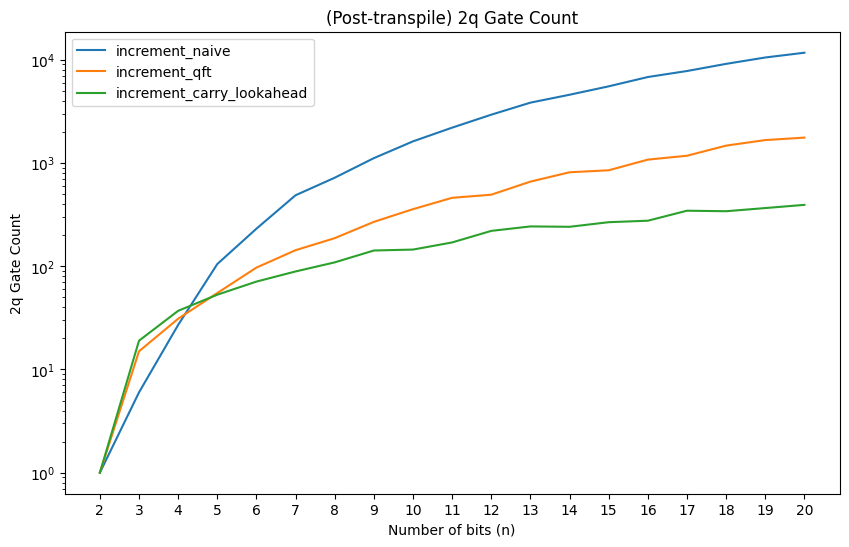

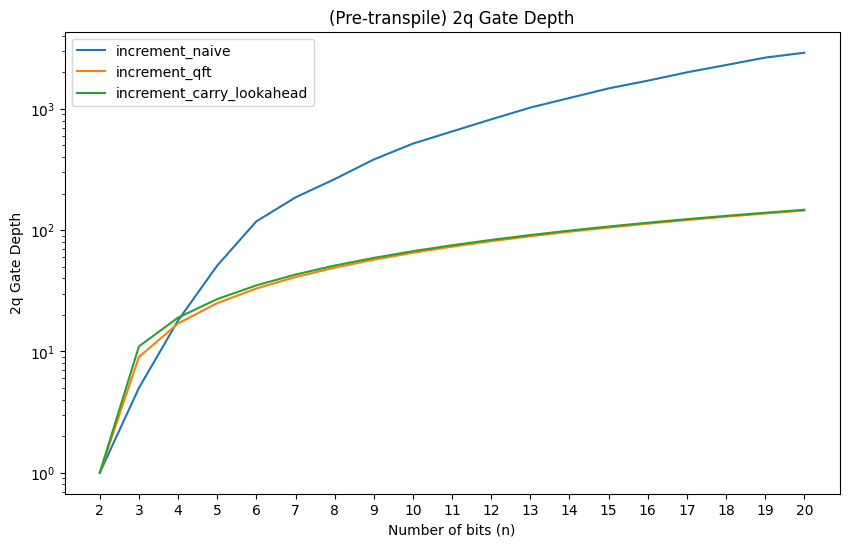

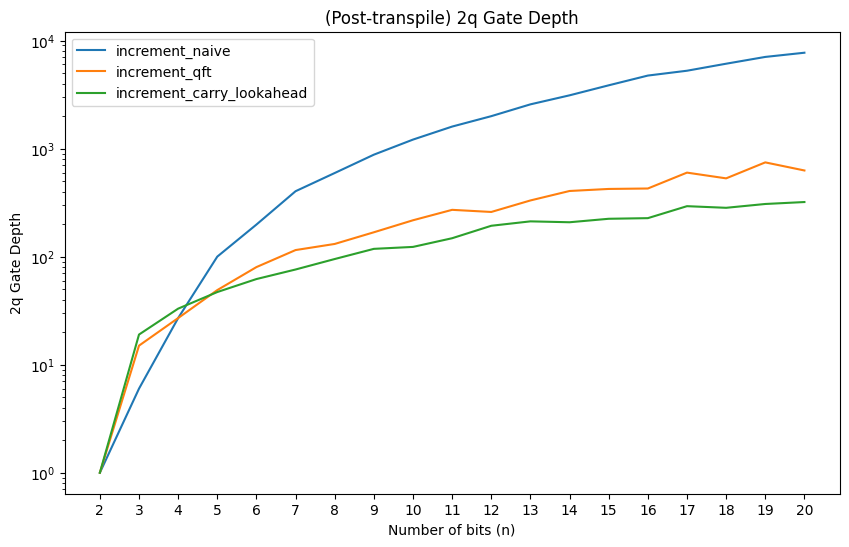

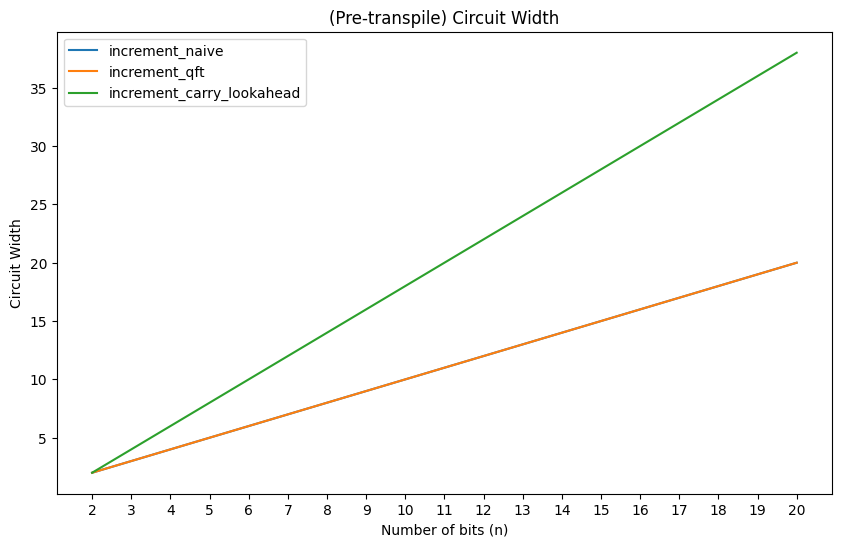

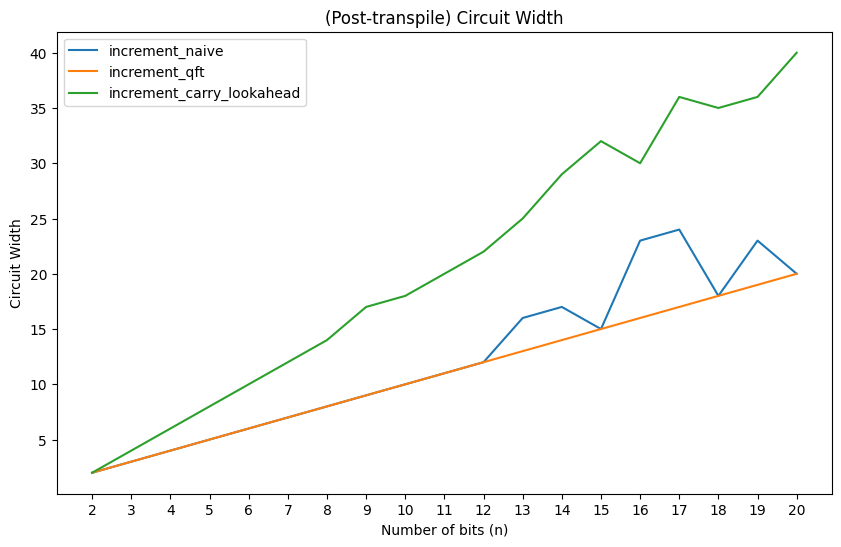

In [12]:
def plot_metric(metric, label, circuit_metrics, logscale=True, skip_decrement=True, final=False):
    x_vals = range(2, 21)
    plt.figure(figsize=(10, 6))
    for candidate in candidates.keys():
        if skip_decrement and candidate.startswith("decrement"):
            continue
        y_vals = [circuit_metrics[(candidate, n)][metric] for n in x_vals]
        plt.plot(x_vals, y_vals, label=candidate)
    plt.xlabel("Number of bits (n)")
    plt.xticks(x_vals)
    plt.ylabel(label)
    if logscale:
        plt.yscale("log")
    if final:
        plt.title(f"(Post-transpile) {label}")
    else:
        plt.title(f"(Pre-transpile) {label}")
    plt.legend()
    plt.savefig(f"plots/metric_{metric}_{'final' if final else ''}.png")
    plt.show()

for metric, label in [("depth", "Depth"), ("2q_count", "2q Gate Count"), ("2q_depth", "2q Gate Depth")]:
    plot_metric(metric, label, circuit_metrics, logscale=True, skip_decrement=True)
    plot_metric(metric, label, final_circuit_metrics, logscale=True, skip_decrement=True, final=True)

plot_metric("num_qubits", "Circuit Width", circuit_metrics, logscale=False, skip_decrement=True)
plot_metric("num_qubits", "Circuit Width", final_circuit_metrics, logscale=False, skip_decrement=True, final=True)

### Fidelity Results

In [52]:
def calculate_fidelity(trial):
    expected_output = trial.extra_data["expected_output"]
    total_shots = sum(trial.counts.values())
    correct_shots = trial.counts.get(expected_output, 0)
    fidelity = correct_shots / total_shots
    return fidelity

In [53]:
trials = db.query(
    select(ExperimentTrial).join(ExperimentTrial.problem).options(joinedload(ExperimentTrial.problem))
    .where(ExperimentProblem.tag == TAG, ExperimentTrial.counts != None)
)
fidelities = {name: [] for name in problems.keys()}
for trial in trials:
    fidelity = calculate_fidelity(trial)
    fidelities[trial.problem.name].append(fidelity)

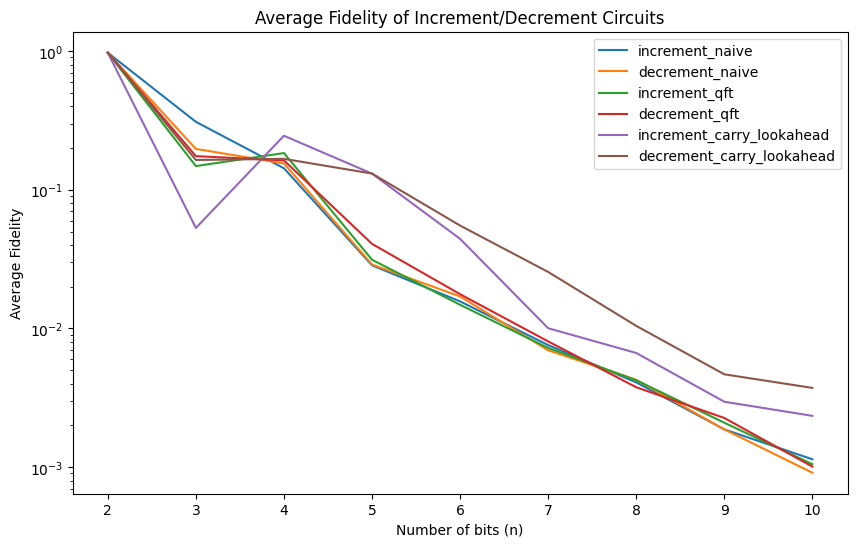

In [55]:
x_vals = range(2, 11)
plt.figure(figsize=(10, 6))
for candidate in candidates.keys():
    y_vals = [np.mean(fidelities[f"{candidate}_n{n}"]) for n in x_vals]
    plt.plot(x_vals, y_vals, label=candidate)
plt.xlabel("Number of bits (n)")
plt.xticks(x_vals)
plt.ylabel("Average Fidelity")
plt.yscale("log")
plt.title("Average Fidelity of Increment/Decrement Circuits")
plt.legend()
plt.savefig("plots/fidelity_comparison.png")
plt.show()